In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd

ct_map = np.load("test/MERSCOPE-liver/data/liver_celltypes_de_novo.npy")
feature_df = pd.read_csv("test/MERSCOPE-liver/data/liver_feature_df.csv",index_col=0)

feature_df

/tmp/ipykernel_431294/1788069889.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,leiden_x,leiden_y,parenchymal,hepatocyte_subtypes
0,-1.281396,5.533049,True,2
1,0.628892,6.953932,True,3
2,1.105134,4.862364,True,1
3,-1.269908,12.927295,True,8
4,-0.238963,2.411054,True,0
5,-1.173488,10.225187,True,5
6,0.840986,8.379825,True,4
7,0.135267,11.158142,True,7
8,-1.657157,10.817456,True,6
9,-1.264161,14.484794,True,9


In [3]:
tissue_matrix = np.zeros((feature_df.parenchymal.sum()+1,)+ct_map.shape)

tissue_matrix[0] = ct_map==12

for i in range(feature_df.parenchymal.sum()):
    idx = list(feature_df.hepatocyte_subtypes).index(i)
    
    tissue_matrix[i+1] = ct_map==idx
    


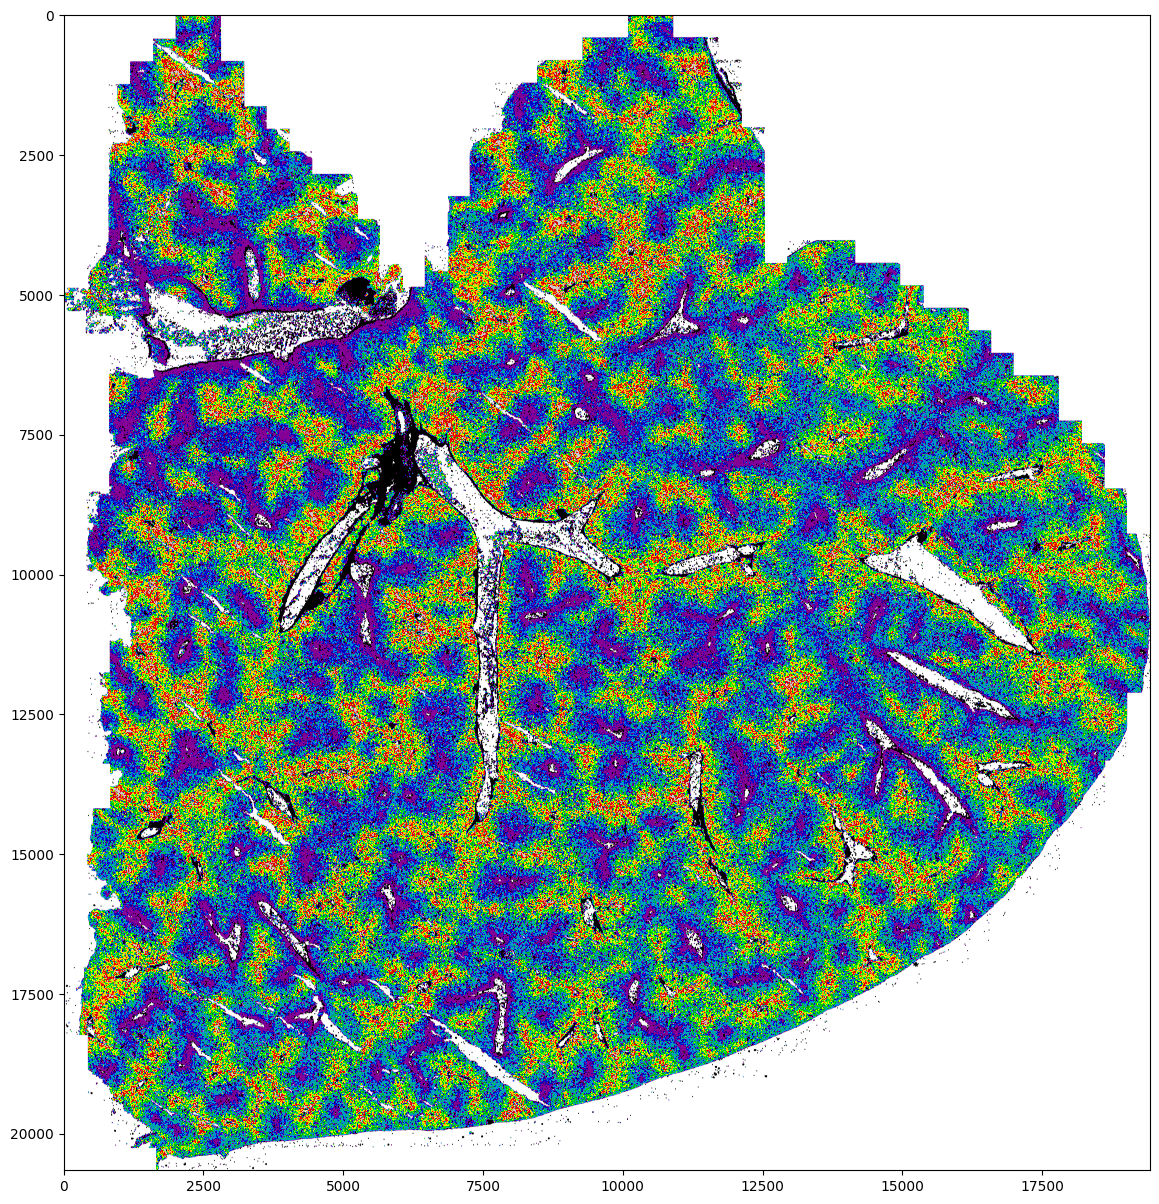

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
plt.imshow(tissue_matrix.argmax(0),cmap='nipy_spectral',alpha=(ct_map!=-1).astype(float))

In [5]:
from sonar import sonar, utils

scaling_factor=0.25

rescaled = utils.rescale_topographic_tensor(tissue_matrix, scaling_factor=scaling_factor).numpy()

In [6]:
import torch

if torch.cuda.is_available():
    import torch as t
    device = 'cuda:0' # put it in a gpu
else:
    import torch as t
    device='cpu'

# unrelated to the NoteBook, the example of a tensor and how to work with it
new_tens = t.zeros(2,2,2, device=device)
new_tens.device

device(type='cpu')

In [11]:
def sig(t, k=1):
    return ((1)/(1+(torch.exp(-t*k))))

def smax(t,k=5):
    return (torch.exp(t*k)/(torch.exp(t*k).sum(0)))

rad_ = 500
linear_radius_steps = 100
lin = 1

son = sonar.Sonar(max_radius=rad_,linear_radius_steps=linear_radius_steps,edge_correction=True)

_,cooc_template_ = son.co_occurrence_from_tensor(rescaled,interpolate=False,area_normalization=True,memory_efficient=True)


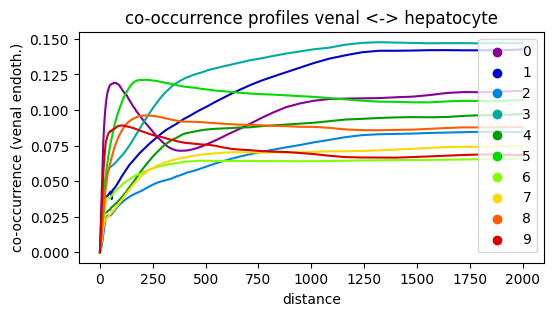

In [12]:
from matplotlib.cm import nipy_spectral
plt.figure(figsize=(6,3))

for i in range(1,cooc_template_.shape[0]):
    plt.plot(son.radii/scaling_factor,cooc_template_[0,i],color=nipy_spectral(i/cooc_template_.shape[0]))
# plt.yscale('log')

# plt.xlim([0,1500])
# plt.ylim([0,0.1])

plt.xlabel('distance')
plt.ylabel('co-occurrence (venal endoth.)')
plt.title('co-occurrence profiles venal <-> hepatocyte')

plt.legend([plt.scatter([],[],color=nipy_spectral((i+1)/cooc_template_.shape[0])) for i in range(cooc_template_.shape[0]-1)],range(cooc_template_.shape[0]-1),)

plt.savefig('output/figures/pancreas_cooc_template.svg',dpi=600)

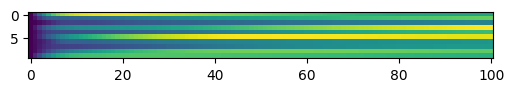

In [33]:
plt.figure(figsize=(6,3))
plt.imshow(cooc_template_[0,1:])